In [1]:
%matplotlib inline
from sklearn.model_selection import train_test_split
import numpy as np
import qutip as qt
from entVAE import vae_utils 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import tensorflow as tf


I0000 00:00:1779100661.752157   36804 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779100661.782480   36804 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779100662.953170   36804 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

In [3]:
n_angle = 101
n_samples = 1000
scan_arr = np.linspace(0, np.pi, n_angle)
alpha_arr = np.zeros(101000)
cnt = 0
for theta in scan_arr:
        for _ in (range(n_samples)):
            alpha_arr[cnt] = theta
            cnt += 1

In [4]:
colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]
markers = ["o", "s", "^", "D", "v", "p"]

MS = 5 
LW = 1.2 
MW = 0.5

# Noisy Dataset  $0.75\beta$

Load Dataset

In [5]:
rho_arr_noisy = np.load('../data/unitary_4x4_101_1000.npy', mmap_mode="r")
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(rho_arr_noisy, alpha_arr, random_state=42)
concurrence_noisy_arr = np.array([qt.concurrence(qt.Qobj(dm.reshape(4,4),dims=[[2,2],[2,2]])) for dm in X_test_noisy])

Load trained VAE and define Hyperparameters:

In [6]:
batch_size = 64
beta = 0.75
learning_rate = 0.0001
lat_dim = 1
hidden_act = "tanh"
final_act = "linear"

encoder, decoder = vae_utils.vae_mlp_4x4(lat_dim, hidden_act, final_act)
encoder.load_weights("../data/encoder_noise_075beta.h5")
decoder.load_weights("../data/decoder_noise_075beta.h5")

vae_noisy = vae_utils.VAE(encoder, decoder, beta)
vae_noisy.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))

z_mean_noisy, z_log_var_noisy, z_noisy = vae_noisy.encoder.predict(X_test_noisy)

790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step


# Beta Scan

In [7]:
inx_dict = {"001":0.01,"01":0.1,"02":0.2,"03":0.3,
            "04":0.4,"05":0.5,"06":0.6,"07":0.7,
            "08":0.8,"09":0.9,"10":1.0,"11":1.1, "12":1.2}
beta_list = [0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2]

In [8]:
def gen_two_largest_z(beta):

    beta_inx = str(beta).replace(".","")
    
    learning_rate = 0.0001
    lat_dim = 8
    hidden_act = "tanh"
    final_act = "linear"

    encoder, decoder = vae_utils.vae_mlp_4x4(lat_dim, hidden_act, final_act)

    encoder.load_weights("../data/grid_8/encoder_{}_grid_8.h5".format(beta_inx))
    decoder.load_weights("../data/grid_8/decoder_{}_grid_8.h5".format(beta_inx))

    vae_beta = vae_utils.VAE(encoder, decoder, beta)
    vae_beta.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))
    history_dict = vae_beta.fit(X_test_noisy, epochs=1, batch_size=64, verbose=0) 
    z_mean_beta, z_log_var_beta, z_beta = vae_beta.encoder.predict(X_test_noisy)
        
    temp_arr = np.zeros(8)
    for i in range(8):
            temp_arr[i] = np.average(vae_utils.kl_loss(z_mean_beta[:,i], z_log_var_beta[:,i]))
    sort_inx = np.argsort(temp_arr)

    return z_mean_beta[:,sort_inx[-1]][::1], z_mean_beta[:,sort_inx[-2]][::1], z_mean_beta

In [9]:
z_001_0, z_001_1,_ = gen_two_largest_z(0.01)
# plt.scatter(z_001_0, z_001_1,c=concurrence_noisy_arr[::1])

z_04_0, z_04_1,_ = gen_two_largest_z(0.4)
# plt.scatter(z_04_0, z_04_1,c=concurrence_noisy_arr[::1])

z_07_0, z_07_1,_ = gen_two_largest_z(0.7)
# plt.scatter(z_07_0, z_07_1,c=concurrence_noisy_arr[::1])

z_1_0, z_1_1,_  = gen_two_largest_z(1.0)
# plt.scatter(z_1_0, z_1_1,c=concurrence_noisy_arr[::1])

790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 340us/step


In [13]:
recon_loss_arr = np.zeros(len(inx_dict))
kl_loss_arr = np.zeros(len(inx_dict))
full_kl_loss_arr = np.zeros((len(inx_dict),8))
full_kl_loss_arr_2 = np.zeros((len(inx_dict),8))

cnt = 0
for inx,beta in inx_dict.items():

    encoder, decoder = vae_utils.vae_mlp_4x4(8, hidden_act, final_act)

    encoder.load_weights("../data/grid_8/encoder_{}_grid_8.h5".format(inx))
    decoder.load_weights("../data/grid_8/decoder_{}_grid_8.h5".format(inx))

    vae_beta = vae_utils.VAE(encoder, decoder, beta)
    vae_beta.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))
    history_dict = vae_beta.fit(X_test_noisy, epochs=1, batch_size=64, verbose=0) 

    recon_loss_arr[cnt] = history_dict.history["reconstruction_loss"][0]
    kl_loss_arr[cnt] = history_dict.history["kl_loss"][0]
    
    z_mean_beta, z_log_var_beta, z_beta = vae_beta.encoder.predict(X_test_noisy)
    
    for i in range(8):
        full_kl_loss_arr[cnt][i] = np.average(vae_utils.kl_loss(z_mean_beta[:,i].astype(np.float64), z_log_var_beta[:,i].astype(np.float64)).astype(np.float64))
        full_kl_loss_arr_2[cnt][i] = np.average(vae_utils.kl_loss(z_mean_beta[:,i], z_log_var_beta[:,i]))

    cnt += 1 

790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 367us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step


In [14]:
row_sums = np.sort(full_kl_loss_arr,axis=-1).sum(axis=1)
new_matrix = np.sort(full_kl_loss_arr,axis=-1) / row_sums[:, np.newaxis]

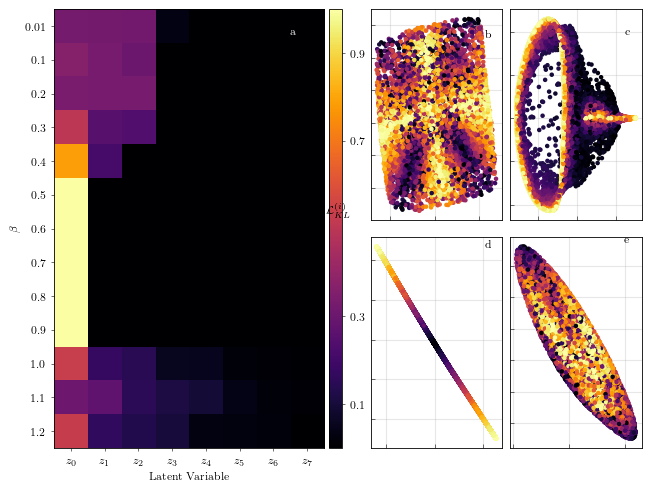

In [15]:
fig = plt.figure(constrained_layout=True)
axs = fig.subplot_mosaic([['Left', 'Top1','Top2'],['Left', 'Bottom1','Bottom2']],
                          gridspec_kw={'width_ratios':[2,0.8,0.8]})  #[2,0.8,0.8]


im = axs['Left'].imshow(np.flip(new_matrix,axis=1),cmap="inferno")

divider = make_axes_locatable(axs['Left'])
cax = divider.append_axes('right', size='5%', pad=0.05)

cbar = plt.colorbar(im, cax=cax, orientation='vertical')
cbar.set_ticks([0.1,0.3,0.7,0.9])

axs['Left'].set_xticks(range(8),["$z_{}$".format(i) for i in range(8)])
axs['Left'].set_yticks(range(len(inx_dict)),["${}$".format(i) for i in beta_list])     

axs['Left'].set_xlabel("Latent Variable")
axs['Left'].set_ylabel("$\\beta$")



axs["Top1"].scatter(z_001_0,z_001_1, c= concurrence_noisy_arr,s=5, cmap="inferno", zorder=3)
axs["Top2"].scatter(z_04_0,z_04_1, c= concurrence_noisy_arr,s=5, cmap="inferno", zorder=3)
axs["Bottom1"].scatter(z_07_0,-z_07_1, c= concurrence_noisy_arr,s=5, cmap="inferno", zorder=3)
axs["Bottom2"].scatter(z_1_0,z_1_1, c= concurrence_noisy_arr,s=5, cmap="inferno", zorder=3)


for a in [axs["Top1"], axs["Top2"], axs["Bottom1"], axs["Bottom2"]]:
    # a.set_box_aspect(1)
    a.grid(True, which="major", linestyle="-", alpha=0.3)
    a.grid(True, which="minor", linestyle=":", alpha=0.15)

    a.tick_params(direction="in", which="both", labelsize=8)
    a.tick_params(which="major", length=3)
    a.tick_params(which="minor", length=1.5)
    # Show ticks but hide the numbers
    a.tick_params(labelbottom=False, labelleft=False)

fig.text(0.444, 0.94, "a",c="white")
fig.text(0.748, 0.932, "b")
fig.text(0.968, 0.94, "c")

fig.text(0.748, 0.495, "d")
fig.text(0.966, 0.505, "e")

fig.text(0.5,0.565,"$\\mathcal{L}_{KL}^{(i)}$")

plt.savefig("fig_exp3.pdf",bbox_inches="tight",pad_inches=0.1)